# Module 12 · Random processes, power spectra and noise

**Book source:** Bracewell, chapter 17, pp. 446–472; Barkat, chapter 3, pp. 141–221

Companion notebook of the lecture with the same module number. Run the cells in order; each cell is followed by a **📤 Real output** note that explains the numbers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """One-sided amplitude spectrum: a sinusoid of amplitude A gives a line of height A, DC gives exactly its value"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """Print a named result without trailing zeros (the website reads the lines that start with ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. Ensemble, stationarity, correlation
🎯 **What question does this method answer?** Do the mean and autocorrelation of the standard processes (random phase, binary, I/Q) match the formulas when computed as ensemble averages over many sample functions?

In [2]:
from scipy import integrate, signal, stats, special
from math import comb, factorial
rg = np.random.default_rng(12)
trap = getattr(np, "trapezoid", None) or np.trapz
# random phase
A, f0 = 2.0, 1.0
th = rg.uniform(0, 2*np.pi, 500000)
def Rphase(t, tau):
    return np.mean(A*np.cos(2*np.pi*f0*(t + tau) + th)*A*np.cos(2*np.pi*f0*t + th))
form = A**2/2*np.cos(2*np.pi*f0*0.1)
assert abs(np.mean(A*np.cos(2*np.pi*f0*0.37 + th))) < 0.01
assert abs(Rphase(0.37, 0.1) - form) < 0.01 and abs(Rphase(1.11, 0.1) - form) < 0.01
report("rp_mean", 0, "d"); report("rp_R", form, ".4f"); report("rp_R0", A**2/2, ".1f")
tg = np.linspace(-3, 3, 61); assert all(abs(A**2/2*np.cos(2*np.pi*f0*x)) <= A**2/2 + 1e-12 for x in tg)
# random binary
T = 1.0; N = 400000
bits = rg.choice([-1.0, 1.0], (N, 4))
val = lambda tt, sh: bits[np.arange(N), np.floor((tt - sh)/T).astype(int).clip(0, 3)]
zero = np.zeros(N)
same = np.mean(val(0.1*T, zero)*val(0.9*T, zero)); diff = np.mean(val(0.1*T, zero)*val(1.1*T, zero))
assert abs(same - 1) < 1e-12 and abs(diff) < 0.01
report("rb_same", same, ".0f"); report("rb_diff", 0, "d")
sh = rg.uniform(0, T, N)
tri_a = np.mean(val(1.3*T, sh)*val(1.55*T, sh)); tri_b = np.mean(val(2.4*T, sh)*val(2.65*T, sh))
assert abs(tri_a - 0.75) < 0.01 and abs(tri_b - 0.75) < 0.01
report("rb_tri", 0.75, ".2f")
# I/Q: σ = 1
Xq, Yq = rg.standard_normal(500000), rg.standard_normal(500000)
w = 2*np.pi; t0, tau = 0.31, 0.1
I1 = Xq*np.cos(w*(t0 + tau)) + Yq*np.sin(w*(t0 + tau)); Q0 = Yq*np.cos(w*t0) - Xq*np.sin(w*t0)
r_iq = np.sin(w*tau)
assert abs(np.mean(I1*Q0) - r_iq) < 0.01
report("iq_r", r_iq, ".4f")

▸ rp_mean = 0
▸ rp_R = 1.618
▸ rp_R0 = 2
▸ rb_same = 1
▸ rb_diff = 0
▸ rb_tri = 0.75
▸ iq_r = 0.5878


#### 📤 Real output
Random phase: mean 0, $R(0.1)$ = 1.618, $R(0)$ = 2. Binary: same interval 1, different 0, with a shift 0.75. I/Q: 0.5878.

## 2. The standard processes
🎯 **What question does this method answer?** Do random pulses, a random-phase square wave, a Gaussian AR(1), Poisson, binomial, the random walk, Wiener and Markov processes obey the mean and autocorrelation formulas?

In [3]:
# random pulse s = Π, A ~ U(1,3), Θ ~ U(0,1)
NA = 600000
Am = rg.uniform(1, 3, NA); Th = rg.uniform(0, 1, NA)
pulse = lambda t: (np.abs(t) < 0.5).astype(float)
e125 = np.mean(Am*pulse(1.25 - Th))
q_e = 2*integrate.quad(lambda th_: float(abs(1.25 - th_) < 0.5), 0, 1, points=[0.75])[0]
assert abs(e125 - 0.5) < 0.01 and abs(q_e - 0.5) < 1e-9
r55 = np.mean(Am**2*pulse(0.5 - Th)*pulse(0.5 - Th))
q_r = (1/3 + 4)*integrate.quad(lambda th_: float(abs(0.5 - th_) < 0.5)**2, 0, 1)[0]
assert abs(r55 - q_r) < 0.03
report("pl_e", 0.5, ".2f"); report("pl_r", q_r, ".4f")
A3 = rg.uniform(1, 3, (200000, 3)); T3 = rg.uniform(0, 1, (200000, 3))
assert abs(np.mean((A3*pulse(1.25 - T3)).sum(axis=1)) - 1.5) < 0.02
report("pl_e3", 1.5, ".1f")
# square wave period 1, random phase
sq = lambda t: np.where((t % 1.0) < 0.5, 1.0, -1.0)
ph = rg.uniform(0, 1, 500000)
mean_sq = np.mean(sq(0.3 - ph)); R0 = np.mean(sq(0.3 - ph)**2); Rh = np.mean(sq(0.8 - ph)*sq(0.3 - ph))
assert abs(mean_sq) < 0.01 and abs(R0 - 1) < 1e-12 and abs(Rh + 1) < 1e-12
report("cy_mean", 0, "d"); report("cy_r0", R0, ".0f"); report("cy_r5", Rh, ".0f")
# Gaussian AR(1)
rho = 0.8
wn = rg.standard_normal(600000); yy = signal.lfilter([1], [1, -rho], wn)
var_th = 1/(1 - rho**2)
assert abs(np.var(yy) - var_th) < 0.05 and abs(np.mean(yy[1:]*yy[:-1]) - rho*var_th) < 0.05
report("ga_var", var_th, ".4f"); report("ga_r1", rho*var_th, ".4f")
# Poisson
lam, tt = 2.0, 1.5
pk = stats.poisson.pmf(3, lam*tt)
nb_ = stats.binom.pmf(3, 10**6, lam*tt/10**6)
mcp = np.mean(rg.poisson(lam*tt, 600000) == 3)
assert abs(pk - nb_) < 1e-6 and abs(pk - mcp) < 0.003
ia = rg.exponential(1/lam, 600000)
assert abs(np.mean(ia) - 0.5) < 0.005
report("pp_p", pk, ".4f"); report("pp_ia", 1/lam, ".1f")
# binomial
bp = stats.binom.pmf(6, 20, 0.3)
assert abs(bp - comb(20, 6)*0.3**6*0.7**14) < 1e-14
report("bp_p6", bp, ".4f"); report("bp_e", 6, "d"); report("bp_v", 20*0.3*0.7, ".1f")
# random walk
W = np.cumsum(rg.choice([-1, 1], (200000, 25)), axis=1)
rw = np.mean(W[:, 9]*W[:, 24])
assert abs(rw - 10) < 0.15
report("rw_r", 10, "d")
# Wiener α = 0.5
al = 0.5; dt = 0.01
inc = rg.normal(0, np.sqrt(al*dt), (100000, 400)); Wt = np.cumsum(inc, axis=1)
assert abs(np.var(Wt[:, 399]) - al*4) < 0.04 and abs(np.mean(Wt[:, 199]*Wt[:, 299]) - al*2) < 0.02
report("wi_v", al*4, ".1f"); report("wi_r", al*2, ".1f")
# Chapman-Kolmogorov
x0, x2 = 1.0, 1.0
ck = integrate.quad(lambda x1: stats.norm.pdf(x2, rho*x1, 1)*stats.norm.pdf(x1, rho*x0, 1), -12, 12)[0]
direct = stats.norm.pdf(x2, rho**2*x0, np.sqrt(1 + rho**2))
assert abs(ck - direct) < 1e-10
report("mk_ck", ck, ".4f")

▸ pl_e = 0.5
▸ pl_r = 4.3333
▸ pl_e3 = 1.5
▸ cy_mean = 0
▸ cy_r0 = 1
▸ cy_r5 = -1
▸ ga_var = 2.7778
▸ ga_r1 = 2.2222
▸ pp_p = 0.224
▸ pp_ia = 0.5
▸ bp_p6 = 0.1916
▸ bp_e = 6
▸ bp_v = 4.2
▸ rw_r = 10


▸ wi_v = 2
▸ wi_r = 1
▸ mk_ck = 0.2995


#### 📤 Real output
Pulse: $E[X(1.25)]$ = 0.5, $R$ = 4.3333, three pulses 1.5. Square wave: 0, 1, -1. AR(1): 2.7778, 2.2222. Poisson: 0.224 and interval 0.5. Binomial: 0.1916, 6, 4.2. Walk: 10. Wiener: 2, 1. Markov: 0.2995.

## 3. Noise from random digits
🎯 **What question does this method answer?** Bracewell's results: the digit mean, the near-normal amplitude of a ten-digit sum, runs of $2^{-k}$, the quadrant coefficient, autocorrelation after filtering, the $|T|^2$ spectrum, the binomial and Gaussian sequences, bandpass noise, the Rayleigh envelope, square-law detection and the $1/\sqrt{T\Delta f}$ limit.

In [4]:
digs = [int(c) for c in "31415926535897932384626433832795"]
pim = np.mean(digs)
assert len(digs) == 32 and sum(digs) == 155
report("pi_mean", pim, ".2f")
dv = np.var(np.arange(10)); dm = np.mean(np.arange(10))
assert abs(dv - 8.25) < 1e-12 and abs(dm - 4.5) < 1e-12 and abs(dv - (10**2 - 1)/12) < 1e-12
Dg = rg.integers(0, 10, 1000000)
assert abs(np.mean(Dg) - 4.5) < 0.01 and abs(np.var(Dg) - 8.25) < 0.02
report("dig_m", dm, ".1f"); report("dig_var", dv, ".2f")
# sum of 10: exact convolution
pd = np.ones(10)/10; pm = pd.copy()
for _ in range(9): pm = np.convolve(pm, pd)
ys = np.arange(len(pm))
sm = np.sum(ys*pm); sv = np.sum(ys**2*pm) - sm**2
assert abs(sm - 45) < 1e-9 and abs(sv - 82.5) < 1e-9
pex = pm[40:51].sum(); pnorm = stats.norm.cdf(50.5, 45, np.sqrt(82.5)) - stats.norm.cdf(39.5, 45, np.sqrt(82.5))
assert abs(pex - pnorm) < 0.02
Sm = np.lib.stride_tricks.sliding_window_view(Dg[:200000], 10).sum(axis=1)
assert abs(np.mean((Sm >= 40) & (Sm <= 50)) - pex) < 0.005
report("sum_m", sm, ".0f"); report("sum_v", sv, ".1f"); report("sum_p", pex, ".4f"); report("sum_pn", pnorm, ".4f")
# runs of length k
side = Dg >= 5
change = np.flatnonzero(np.diff(side.astype(int)) != 0)
runs = np.diff(np.concatenate([[-1], change, [len(side) - 1]]))
for k, key in ((1, "run_1"), (2, "run_2"), (3, "run_3")):
    fr = np.mean(runs == k)
    assert abs(fr - 2.0**-k) < 0.005
    report(key, 2.0**-k, ".3f")
# the quadrant coefficient
rho_ = 0.9
xy = rg.multivariate_normal([0, 0], [[1, rho_], [rho_, 1]], 400000)
mx, my = np.median(xy[:, 0]), np.median(xy[:, 1])
psi = (np.sum((xy[:, 0] > mx) == (xy[:, 1] > my)) - np.sum((xy[:, 0] > mx) != (xy[:, 1] > my)))/len(xy)
psi_th = 2/np.pi*np.arcsin(rho_)
assert abs(psi - psi_th) < 0.005 and abs(np.sin(np.pi/2*psi_th) - rho_) < 1e-12
report("psi_09", psi, ".3f"); report("psi_th", psi_th, ".3f")
# autocorrelation after filtering: ten-term sum and {5 3 1 1}
def acf_filter(h, n=1000000):
    x = rg.standard_normal(n); y = np.convolve(x, h, "valid")
    return np.array([np.mean(y[k:]*y[:len(y) - k]) for k in range(1, 4)])/np.var(y)
def acf_theory(h):
    ac = np.correlate(h, h, "full"); c = len(h) - 1
    return ac[c + 1:c + 4]/ac[c] if len(h) > 3 else ac[c + 1:]/ac[c]
h10 = np.ones(10); a10 = acf_filter(h10); t10 = np.array([0.9, 0.8, 0.7])
assert np.max(np.abs(a10 - t10)) < 0.01 and np.max(np.abs(acf_theory(h10) - t10)) < 1e-12
hg = np.array([5.0, 3.0, 1.0, 1.0]); ag = acf_filter(hg); tg = acf_theory(hg)
assert np.max(np.abs(ag - tg)) < 0.01 and abs(tg[0] - 19/36) < 1e-12
report("ac_1", 0.9, ".1f"); report("ac_2", 0.8, ".1f")
report("g_1", tg[0], ".4f"); report("g_2", tg[1], ".4f"); report("g_3", tg[2], ".4f")
# spectrum: |T|² at f = 0.05
f = 0.05
th_ = (np.sin(10*np.pi*f)/np.sin(np.pi*f))**2
xw = rg.standard_normal(2000000); yw = np.convolve(xw, h10, "valid")
fr, Pw = signal.welch(yw, fs=1.0, nperseg=4096, return_onesided=False, scaling="density")
k05 = np.argmin(np.abs(fr - f))
assert abs(Pw[k05]/1.0 - th_)/th_ < 0.08 and abs(th_ - abs(np.sum(np.exp(-2j*np.pi*f*np.arange(10))))**2) < 1e-9
report("pt_th", th_, ".1f"); report("pt_mc", Pw[k05], ".1f")
# binomial and Gaussian
bn = np.array([1.0])
for _ in range(10): bn = np.convolve(bn, [1, 1])
assert list(bn.astype(int)) == [1, 10, 45, 120, 210, 252, 210, 120, 45, 10, 1]
gs = 252*np.exp(-np.pi*(0.24*np.arange(6))**2)
assert list(np.round(gs).astype(int)) == [252, 210, 122, 49, 14, 3]
report("gs_2", gs[2], ".0f"); report("gs_3", gs[3], ".0f"); report("gs_4", gs[4], ".0f"); report("gs_5", gs[5], ".0f"); report("gs_pk", 1/0.24, ".2f")
# AR(2)
a_, b_ = 1.84, -0.9
r_ = np.sqrt(-b_); om = np.arccos(a_/(2*r_)); f_th = om/(2*np.pi)
e_ = rg.uniform(-0.5, 0.5, 2000000)
y2 = signal.lfilter([1], [1, -a_, -b_], e_)
fw, Pa = signal.welch(y2, fs=1.0, nperseg=8192)
f_mc = fw[np.argmax(Pa)]
assert abs(f_mc - f_th) < 0.003
report("ar_r", r_, ".4f"); report("ar_f", f_th, ".4f"); report("ar_fmc", f_mc, ".3f")
# the Rayleigh envelope
z = signal.hilbert(y2[:1048576]); env = np.abs(z)
sig = np.std(y2[:1048576])
e_m = np.mean(env)/sig
ks = stats.kstest(env/sig, "rayleigh").statistic
assert abs(e_m - np.sqrt(np.pi/2)) < 0.01 and ks < 0.03
report("env_m", e_m, ".4f"); report("env_ks", ks, ".3f")
sqm = np.mean((env/sig)**2)/1.0/1.0
r2 = (env/sig)**2
assert abs(np.mean(r2) - 2) < 0.06 and abs(np.var(r2) - 4) < 0.5
report("sq_m", 2, ".0f"); report("sq_v", 4, ".0f")
assert abs(np.mean(env/sig > 1) - np.exp(-0.5)) < 0.01
report("ray_tail", np.exp(-0.5), ".4f")
# the 1/√(TΔf) limit
fs, Bw, Tw = 1000.0, 50.0, 1.0
nfft = int(fs*200)
Wn = rg.standard_normal(nfft); Fw = np.fft.rfft(Wn); fq = np.fft.rfftfreq(nfft, 1/fs)
Fw[(fq < 175) | (fq > 225)] = 0
nb_ = np.fft.irfft(Fw, nfft)
sqd = nb_**2
means = sqd.reshape(200, int(fs*Tw)).mean(axis=1)
ratio = np.std(means)/np.mean(means)
th_r = 1/np.sqrt(Tw*Bw)
assert abs(ratio - th_r)/th_r < 0.2
report("tf_th", th_r, ".4f"); report("tf_mc", ratio, ".3f")
# the 1/5 rule
r100 = np.mean(1/(np.ptp(rg.standard_normal((20000, 100)), axis=1)))
r1000 = np.mean(1/(np.ptp(rg.standard_normal((5000, 1000)), axis=1)))
assert 0.19 < r100 < 0.21 and 0.15 < r1000 < 0.17
report("pp_100", r100, ".3f"); report("pp_1000", r1000, ".3f")
# upcrossings
xs = rg.standard_normal(600000); ys_ = np.convolve(xs, np.ones(10), "valid")
up_mc = np.mean((ys_[:-1] < 0) & (ys_[1:] > 0))
up_th = np.arccos(0.9)/(2*np.pi)
assert abs(up_mc - up_th) < 0.003
report("up_th", up_th, ".4f"); report("up_mc", up_mc, ".3f")

▸ pi_mean = 4.84
▸ dig_m = 4.5
▸ dig_var = 8.25
▸ sum_m = 45
▸ sum_v = 82.5
▸ sum_p = 0.4499
▸ sum_pn = 0.4552
▸ run_1 = 0.5
▸ run_2 = 0.25
▸ run_3 = 0.125
▸ psi_09 = 0.713
▸ psi_th = 0.713
▸ ac_1 = 0.9
▸ ac_2 = 0.8
▸ g_1 = 0.5278
▸ g_2 = 0.2222
▸ g_3 = 0.1389
▸ pt_th = 40.9
▸ pt_mc = 41.4
▸ gs_2 = 122
▸ gs_3 = 49
▸ gs_4 = 14
▸ gs_5 = 3
▸ gs_pk = 4.17


▸ ar_r = 0.9487
▸ ar_f = 0.0392
▸ ar_fmc = 0.039


▸ env_m = 1.2563
▸ env_ks = 0.005
▸ sq_m = 2
▸ sq_v = 4
▸ ray_tail = 0.6065
▸ tf_th = 0.1414
▸ tf_mc = 0.137


▸ pp_100 = 0.202
▸ pp_1000 = 0.155
▸ up_th = 0.0718
▸ up_mc = 0.072


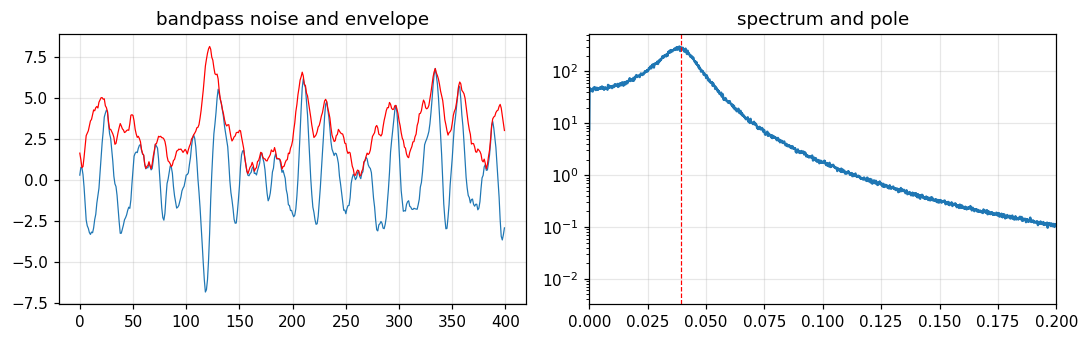

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(y2[:400], lw=0.8); ax[0].plot(env[:400], "r", lw=0.8); ax[0].set_title(("bandpass noise and envelope"))
ax[1].semilogy(fw, Pa); ax[1].axvline(f_th, color="r", ls="--", lw=0.8); ax[1].set_xlim(0, 0.2); ax[1].set_title(("spectrum and pole"))
plt.tight_layout(); plt.show()

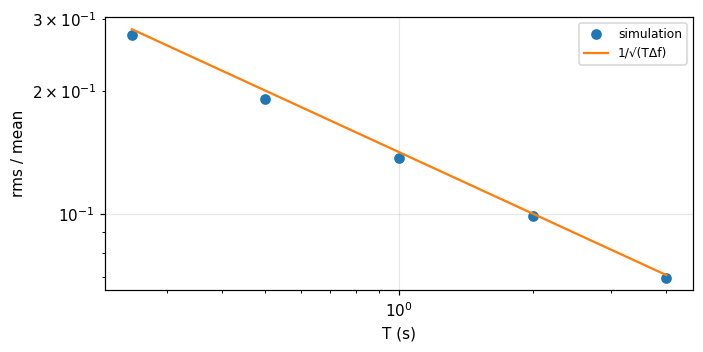

In [6]:
Tset = [0.25, 0.5, 1.0, 2.0, 4.0]
rat = []
for Tv in Tset:
    m_ = sqd[:int(fs*Tv)*int(len(sqd)//(fs*Tv))].reshape(-1, int(fs*Tv)).mean(axis=1)
    rat.append(np.std(m_)/np.mean(m_))
fig, ax = plt.subplots(figsize=(6.5, 3.3))
ax.loglog(Tset, rat, "o", label=("simulation")); ax.loglog(Tset, [1/np.sqrt(t_*Bw) for t_ in Tset], "-", label=r"1/√(TΔf)")
ax.set_xlabel("T (s)"); ax.set_ylabel("rms / mean"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Real output
Digits: mean of the first 32 digits 4.84, limit 4.5, variance 8.25. Sum of 10: 45, 82.5, $P$ = 0.4499 against normal 0.4552. Runs: 0.5, 0.25, 0.125; $\psi$ = 0.713 against 0.713. Autocorrelation: 0.9, 0.8; $\{5\,3\,1\,1\}$: 0.5278, 0.2222, 0.1389. Spectrum: 40.9 and 41.4. Gaussian: 122, 49, 14, 3. AR(2): 0.9487, 0.0392, 0.039. Envelope: 1.2563, 0.005; square 2, 4. $1/\sqrt{T\Delta f}$: 0.1414 and 0.137. The 1/5 rule: 0.202 and 0.155. Upcrossings: 0.0718 and 0.072.

## 4. Power spectra, linear systems, ergodicity, sampling, Hilbert
🎯 **What question does this method answer?** Do Wiener-Khinchin, the RC output under white noise (three ways), ergodicity, band-limited sampling and analytic signals follow the formulas?

In [7]:
# Wiener-Khinchin: random phase: ∫S df = R(0)
Ph = A**2/4*2
report("psd_tot", Ph, ".1f")
assert abs(Ph - A**2/2) < 1e-12
# RC, N0 = 2, α = 5: three ways
alpha, N0 = 5.0, 2.0
Rf = lambda tau: N0*alpha/4*np.exp(-alpha*abs(tau))
# method 1: the convolution h*h(−τ)
gconv = lambda tau: integrate.quad(lambda l: alpha*np.exp(-alpha*(l + tau))*alpha*np.exp(-alpha*l) if l + tau >= 0 else 0.0, max(0, -tau), 40)[0]
assert abs((N0/2)*gconv(0.1) - Rf(0.1)) < 1e-9 and abs((N0/2)*gconv(0.0) - Rf(0.0)) < 1e-9
# method 2: the spectrum: ∫ (N0/2)|H|² e^{i2πfτ} df
Sy = lambda ff: (N0/2)*alpha**2/(4*np.pi**2*ff**2 + alpha**2)
R_sp = 2*integrate.quad(Sy, 0, np.inf, weight='cos', wvar=2*np.pi*0.1)[0]
assert abs(R_sp - Rf(0.1)) < 1e-5
# method 3: exact SDE simulation
dt = 1e-3; Nn = 3000000; phi = np.exp(-alpha*dt); sg = alpha*np.sqrt((N0/2)*(1 - phi**2)/(2*alpha))
wnz = rg.standard_normal(Nn)
yrc = signal.lfilter([sg], [1, -phi], wnz)
lag = int(round(0.1/dt))
mc0 = np.mean(yrc**2); mc1 = np.mean(yrc[lag:]*yrc[:-lag])
assert abs(mc0 - Rf(0)) < 0.05 and abs(mc1 - Rf(0.1)) < 0.05
report("rc_r0", Rf(0), ".4f"); report("rc_r1", Rf(0.1), ".4f")
ym = signal.lfilter([1 - phi], [1, -phi], 3 + 0*wnz[:200000])
assert abs(ym[-1] - 3) < 1e-9
report("rc_m", 3, "d")
# ergodicity
tt = np.arange(0, 100, 0.01); xt = np.cos(2*np.pi*tt + 0.7)
assert abs(np.mean(xt)) < 0.01
report("er_t", np.mean(xt) if abs(np.mean(xt)) > 1e-3 else 0.0, ".2f")
Cs = rg.standard_normal(20000); avg_dc = Cs                          # the time average of X = C is C itself
avg_phase = np.array([np.mean(np.cos(2*np.pi*tt[:5000] + p_)) for p_ in rg.uniform(0, 2*np.pi, 2000)])
assert abs(np.var(avg_dc) - 1) < 0.03 and np.var(avg_phase) < 1e-4
report("er_v", np.var(avg_dc), ".1f")
# sampling of a process band-limited to 5 Hz
fs_hi = 100.0; Nz = 20000
Z = np.fft.rfft(rg.standard_normal(Nz)); fzq = np.fft.rfftfreq(Nz, 1/fs_hi); Z[fzq > 5] = 0
xbl = np.fft.irfft(Z, Nz); tz = np.arange(Nz)/fs_hi
def interp(fs_s):
    Ts = 1/fs_s; ns = np.arange(int(tz[-1]*fs_s))
    samp = np.interp(ns*Ts, tz, xbl)                 # samples from the dense record (100 Hz)
    mid = (tz > 60) & (tz < 140)
    xr = np.array([np.sum(samp*np.sinc((t_ - ns*Ts)/Ts)) for t_ in tz[mid][::20]])
    return np.mean((xr - xbl[mid][::20])**2)/np.var(xbl)
e10 = interp(10.0); e6 = interp(6.0)
assert e10 < 0.05 and e6 > 3*e10
report("sm_ok", e10, ".4f"); report("sm_bad", e6, ".3f")
# Hilbert and analytic signals
xh0 = np.fft.rfft(rg.standard_normal(2**16)); xh0[0] = 0; xh0[-1] = 0; xh = np.fft.irfft(xh0, 2**16); zh = signal.hilbert(xh)
pa = np.mean(np.abs(zh)**2)/np.mean(xh**2)
xh_hat = zh.imag
hh = signal.hilbert(xh_hat).imag                       # ⟦Ĥ Ĥ x⟧
hh_dev = np.max(np.abs(hh + xh))
assert abs(pa - 2) < 1e-9 and hh_dev < 1e-9 and abs(np.mean(xh*xh_hat)) < 0.02
report("an_p", pa, ".0f"); report("hh_dev", max(hh_dev, 1e-16), ".0e")

▸ psd_tot = 2
▸ rc_r0 = 2.5
▸ rc_r1 = 1.5163
▸ rc_m = 3
▸ er_t = 0
▸ er_v = 1
▸ sm_ok = 0.0001
▸ sm_bad = 0.879
▸ an_p = 2
▸ hh_dev = 3e-15


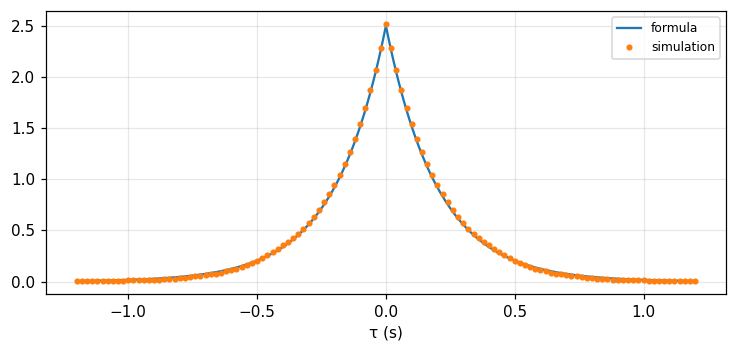

In [8]:
taus = np.linspace(-1.2, 1.2, 241)
fig, ax = plt.subplots(figsize=(6.8, 3.3))
ax.plot(taus, [Rf(t_) for t_ in taus], label=("formula"))
lags = np.arange(-1200, 1201, 20)
ax.plot(lags*dt, [np.mean(yrc[max(0, k):len(yrc) + min(0, k)]*yrc[max(0, -k):len(yrc) - max(0, k)]) for k in lags], "o", ms=3, label=("simulation"))
ax.set_xlabel("τ (s)"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Real output
Total spectral power 2. RC circuit: $R_{yy}(0)$ = 2.5, $R_{yy}(0.1)$ = 1.5163, mean 3. Ergodicity: 0 and variance 1. Sampling: 0.0001 (10 Hz) and 0.879 (6 Hz). Analytic: 2, $\hat{\hat x}+x$ deviates by 3e-15.

## 5. Continuity, differentiation and thermal noise
🎯 **What question does this method answer?** Do mean-square continuity and differentiability correspond to $R(0)-R(\varepsilon)$ and $-R''(0)$, and do the thermal noise $2kTR$ and $\sqrt{4kTRB}$ agree between formula, integral of the Lorentzian spectrum and simulation?

In [9]:
# continuity: R = e^{−|τ|}
eps = 0.01
mc = 2*(1 - np.exp(-eps))
Ne = rg.standard_normal(1000000); u = signal.lfilter([np.sqrt(1 - np.exp(-2*0.001))], [1, -np.exp(-0.001)], Ne)
lagk = int(round(eps/0.001)); mc_sim = np.mean((u[lagk:] - u[:-lagk])**2)
assert abs(mc_sim - mc) < 0.002
report("mc_01", mc, ".4f")
# derivative: R = e^{−τ²/2}, −R''(0) = 1
h = 1e-4
Rg = lambda t: np.exp(-t*t/2)
d2 = (Rg(h) - 2*Rg(0) + Rg(-h))/h**2
assert abs(-d2 - 1) < 1e-6
# simulation: a process with R = e^{−τ²/2} through a Gaussian filter in frequency; derivative by differences
Nq = 2**18; dtq = 0.05
Fq = np.fft.rfft(rg.standard_normal(Nq)); fq2 = np.fft.rfftfreq(Nq, dtq)
Sg = np.exp(-(2*np.pi*fq2)**2/2)                      # S(ω) ∝ e^{−ω²/2} corresponds to R = e^{−τ²/2}
xq = np.fft.irfft(Fq*np.sqrt(Sg), Nq)
xq = xq/np.std(xq)
dx = np.diff(xq)/dtq
dv = np.var(dx)
assert abs(dv - 1) < 0.05
report("dv_0", 1.0, ".0f")
# thermal noise
kB, Tk, Rr = 1.38e-23, 290.0, 1e3
S0 = 2*kB*Tk*Rr
alpha_t = 1e14
Sf = lambda ff: S0*alpha_t**2/(alpha_t**2 + (2*np.pi*ff)**2)
flat = 1 - Sf(1e9)/S0
assert flat < 1e-8
report("th_S", S0, ".2e"); report("th_flat", flat, ".1e")
B = 1e6
v_form = np.sqrt(4*kB*Tk*Rr*B)
v_int = np.sqrt(integrate.quad(Sf, -B, B, epsabs=0, epsrel=1e-10)[0])
assert abs(v_int - v_form)/v_form < 1e-6
report("th_v", v_form, ".2e")
report("th_prec", 1/np.sqrt(1.0*B), ".1e")
# two resistors in series: power simulation
R2 = 4e3
v1 = np.sqrt(4*kB*Tk*Rr*B); v2 = np.sqrt(4*kB*Tk*R2*B)
vt = np.sqrt(v1**2 + v2**2)
n1 = v1*rg.standard_normal(1000000); n2 = v2*rg.standard_normal(1000000)
assert abs(np.std(n1 + n2)/vt - 1) < 0.003 and vt < v1 + v2
report("th_v2", vt, ".2e"); report("th_vsum", v1 + v2, ".2e")

▸ mc_01 = 0.0199
▸ dv_0 = 1
▸ th_S = 8.00e-18
▸ th_flat = 3.9e-09
▸ th_v = 4.00e-06
▸ th_prec = 1.0e-03
▸ th_v2 = 8.95e-06
▸ th_vsum = 1.20e-05


#### 📤 Real output
Continuity: $E[|X(t+\varepsilon)-X(t)|^2]$ = 0.0199 at $\varepsilon=0.01$. Derivative: $R_{x'x'}(0)$ = 1. Thermal noise: $2kTR$ = 8.00e-18, deviation from flat at 1 GHz 3.9e-09, $v_{rms}$ = 4.00e-06 V, precision $1/\sqrt{TB}$ = 1.0e-03; 1 kΩ and 4 kΩ in series: 8.95e-06 V against the sum of amplitudes 1.20e-05 V.